In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import matplotlib.pyplot as plt

helper funcs

In [2]:
#slsqp numeric solver for exact optimal weights with ftol 1e-6
#transform to log space for numerical stability
def get_exact_weights(relvar,trade,Delta=1):
    Q = trade.sum(axis=1)
    Q_scaled = Q / np.mean(Q)

    #scale for stability
    relvar_scaled = relvar / np.linalg.norm(relvar)

    N = len(Q)

    def f_opt(y):
        # Clip y to prevent overflow in exp
        y_clipped = np.clip(y, -50, 0)
        x = np.exp(y_clipped)

        quad = 0.5 * x.T @ relvar_scaled @ x
        recip = np.sum(Q_scaled / x)

        # Ensure positive values before taking log
        if quad <= 0 or recip <= 0:
            return 1e10  # Return large penalty value
        
        # log objective for numerical stability
        return np.log(quad) + np.log(recip)

    #weights sum to 1
    def portfolio_constraint(y):
            y_clipped = np.clip(y, -10, 0)
            x = np.exp(y_clipped)
            return np.sum(x) - 1

    # initial guess is equal weights
    x0 = np.ones(N) / (N)
    y0 = np.log(x0)
    bounds = [(-10, 0)] * N  # bounds to prevent overflow

    # ---- exact solution ----
    res_exact = minimize(
        f_opt,
        y0,
        method="SLSQP",
        bounds=bounds,  # Enable bounds
        constraints=[{'type': 'eq', 'fun': portfolio_constraint}],
        options={"maxiter": 10000, "ftol": 1e-6}  # ftol
    )
    x_opt = np.exp(np.clip(res_exact.x, -10, 0)) #transform back to x
    
    if res_exact.success == False:
        print(res_exact.message)
        print(res_exact.status)
    if f_opt(y0) < f_opt(res_exact.x): #if solver failed for some reason and it worse than equal weights just use equal weights
        x_opt = x0
    return x_opt


In [3]:
def get_var_weighted(cov,trade,Delta=1):
    D = trade.sum(axis=1)
    sigma2 = cov.sum(axis=1)
    x = np.sqrt(D)/sigma2
    x = x/np.sum(x)
    return x

def expected_cost_multi(cov,trade,weight_func,Delta=1):
  D = trade.sum(axis=1)
  w = weight_func(cov,trade)
  sigma_w = w.T @ cov @ w/2
  totalQ = np.triu(trade).sum()
  return np.sqrt(Delta * sigma_w * np.sum(D/w))

def expected_cost_status_quo(cov,trade,Delta=1):
  D = trade.sum(axis=1)
  totalQ = np.triu(trade).sum()
  try:
    sigma2 = cov['USD']
  except:
    sigma2 = cov[0,:]
  return np.sum(np.sqrt(Delta * sigma2 * D))

In [4]:
#use ex-ante expectations for liquidity provision decisions and ex-post for realized
def realized_cost_multi(Erelvar,Etrade,weight_func,real_trade,Delta=1):
  #use expected/estimated values to calculate weights, V, and f
  EQ = Etrade.sum(axis=1)
  w = weight_func(Erelvar,Etrade,Delta)
  H_w = w.T @ Erelvar @ w/2
  EtotalQ = np.triu(Etrade).sum()
  f = np.sqrt(Delta * H_w/(4*EtotalQ**2) * np.sum(EQ/w))
  V = 2*f*EtotalQ/H_w

  #use realized values (current window) to calculate realized cost
  real_Q = real_trade.sum(axis=1)
  real_totalQ = np.triu(real_trade).sum()
  c = Delta/(2*V) * np.sum(real_Q/w) + f*real_totalQ
  return c

def realized_cost_status_quo(Erelvar,Etrade,real_trade,Delta=1):
  real_Q = real_trade.sum(axis=1) #real volume
  EQ = Etrade.sum(axis=1) #expected volume
  sigma2 = Erelvar['USD']
  return np.sum(np.sqrt(Delta * sigma2/EQ)*real_Q)

In [5]:
def get_trade_sub(trade,group):
    pool = ['USD'] + group
    others = trade.columns.difference(pool)
    trade_sub = trade.loc[pool,pool]
    #trades to currencies outside pool are routed through USD here so add the volume to ccy <-> usd volume
    effective_trades_out = trade.loc[pool,others].sum(axis=1)
    trade_sub['USD'] += effective_trades_out
    trade_sub.loc['USD'] += effective_trades_out
    trade_sub.loc['USD','USD'] = 0 #double check make sure this is zero
    np.fill_diagonal(trade_sub.values, 0) #double check make sure diagonal is zero
    return trade_sub

def get_relvar_sub(relvar,group):
    pool = ['USD'] + group
    relvar_sub = relvar.loc[pool,pool] #cov is unchanged
    return relvar_sub

def get_realized_selection_cost_multi(groups,Etrade,Erelvar,real_trade):
  pool_cost = 0
  for group in groups: #pair does not include usd
      if len(group) < 2:
         continue
      #effective trade is for each pool currency, sum of all trades with other currencies go through usd
      Etrade_sub = get_trade_sub(Etrade,group)
      Erelvar_sub = get_relvar_sub(Erelvar,group)
      real_trade_sub = get_trade_sub(real_trade,group)

      #calculate pool cost
      # total_pool_trade = np.triu(trade_sub.values).sum()
      cost = realized_cost_multi(Erelvar_sub,Etrade_sub,get_exact_weights,real_trade_sub)
      pool_cost += cost#/100*total_pool_trade

  #any ungrouped currency just does everything through USD
  pooled_currencies = [item for sublist in groups for item in sublist if len(sublist) >= 2]
  if len(pooled_currencies)+1 < len(Etrade.columns):
    ungrouped = Etrade.columns.difference(pooled_currencies+['USD']).to_list() #does not include usd, but this is not that important because
    #usd-usd relvar is zero anyway
    #any trades to pooled currencies already have other leg accounted for so add the volume to USD volume to account for this leg
    #otherwise it's just status quo
    Etrade_sub = get_trade_sub(Etrade,ungrouped)
    Erelvar_sub = get_relvar_sub(Erelvar,ungrouped)
    real_trade_sub = get_trade_sub(real_trade,ungrouped)

    external_cost = realized_cost_status_quo(Erelvar_sub,Etrade_sub,real_trade_sub)
  else:
    external_cost = 0

  return pool_cost + external_cost

load data

In [6]:
import csv
quarters = []
with open('data/quarters_list.csv', mode='r') as file:
    reader = csv.reader(file)
    for row in reader:
        quarters.append(row[0])

print(quarters)

['2008Q1', '2008Q2', '2008Q3', '2008Q4', '2009Q1', '2009Q2', '2009Q3', '2009Q4', '2010Q1', '2010Q2', '2010Q3', '2010Q4', '2011Q1', '2011Q2', '2011Q3', '2011Q4', '2012Q1', '2012Q2', '2012Q3', '2012Q4', '2013Q1', '2013Q2', '2013Q3', '2013Q4', '2014Q1', '2014Q2', '2014Q3', '2014Q4', '2015Q1', '2015Q2', '2015Q3', '2015Q4', '2016Q1', '2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2', '2017Q3', '2017Q4', '2018Q1', '2018Q2', '2018Q3', '2018Q4', '2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4']


In [7]:
rolling_relvar = {}
rolling_trade = {}
quarterly_trade = {}
for quarter in quarters:
    rolling_relvar[quarter] = pd.read_csv(f"data/rolling_windows/relvars/{quarter}.csv",index_col=0)
    rolling_trade[quarter] = pd.read_csv(f"data/rolling_windows/trade/{quarter}.csv",index_col=0)
    quarterly_trade[quarter] = pd.read_csv(f"data/realized_volumes/{quarter}.csv",index_col=0)

evaluate

In [13]:
#HAC
pools = [['ALL', 'CHF', 'CZK', 'EUR', 'GBP', 'JPY', 'NOK', 'PLN', 'RSD', 'SEK'], ['AUD', 'ISK', 'NZD'], ['COP', 'TRY'], ['KRW', 'SGD', 'THB']]
#Greedy <= 3-asset pools
# pools = [['EUR', 'GBP'], ['CZK', 'PLN'], ['NOK', 'SEK'], ['AUD', 'NZD'], ['ALL', 'RSD'], ['CDF', 'TZS'], ['SGD', 'THB'], ['JPY', 'KRW'], ['KES', 'UGX'], ['BRL', 'CLP'], ['COP', 'TRY'], ['PYG', 'UYU'], ['MZN', 'ZAR'], ['CHF', 'ISK'], ['BIF', 'CAD'], ['MXN', 'PHP'], ['GHS', 'INR'], ['IDR', 'MUR'], ['AMD', 'JMD'], ['DZD', 'PEN'], ['GTQ', 'NIO']]
#Greedy <= 7-asset pools
# pools = [['CHF', 'CZK', 'EUR', 'GBP', 'RSD', 'SEK'], ['AUD', 'NZD'], ['JPY', 'KRW', 'SGD', 'THB'], ['CDF', 'TZS'], ['ALL', 'ISK', 'NOK', 'PLN'], ['BIF', 'BRL', 'CLP', 'COP', 'TRY'], ['KES', 'UGX'], ['PYG', 'UYU'], ['MZN', 'ZAR'], ['GHS', 'MXN', 'PHP'], ['CAD', 'MUR'], ['INR', 'PEN'], ['AMD', 'IDR'], ['DZD', 'JMD'], ['GTQ', 'NIO']]
results = []
for quarter in quarters:
  Erelvar = rolling_relvar[quarter]
  Etrade = rolling_trade[quarter]
  real_trade = quarterly_trade[quarter]
  volume = np.triu(real_trade.values).sum()
  results.append({
            "quarter": quarter,
            "selection_cost": get_realized_selection_cost_multi(pools,Etrade,Erelvar,real_trade),
            "status_quo": realized_cost_status_quo(Erelvar,Etrade,real_trade),
            "total_trade": volume
  })
results_df = pd.DataFrame(results)

results_df['quarter'] = pd.PeriodIndex(results_df['quarter'], freq='Q').to_timestamp()

selection_total = results_df['selection_cost'].sum()
status_quo_total = results_df['status_quo'].sum()
total_trade = results_df['total_trade'].sum()

print("total aggregates over 2008-2023")
print("total trade",total_trade)
print("selection",selection_total)
print("vehicle routing",status_quo_total)
print("difference",status_quo_total-selection_total)
print("selection/vehicle routing",selection_total/status_quo_total)
print("percent savings",(1-selection_total/status_quo_total)*100)

total aggregates over 2008-2023
total trade 109443088.799621
selection 16453.971359646865
vehicle routing 18934.674067766893
difference 2480.7027081200285
selection/vehicle routing 0.8689862471758619
percent savings 13.101375282413807


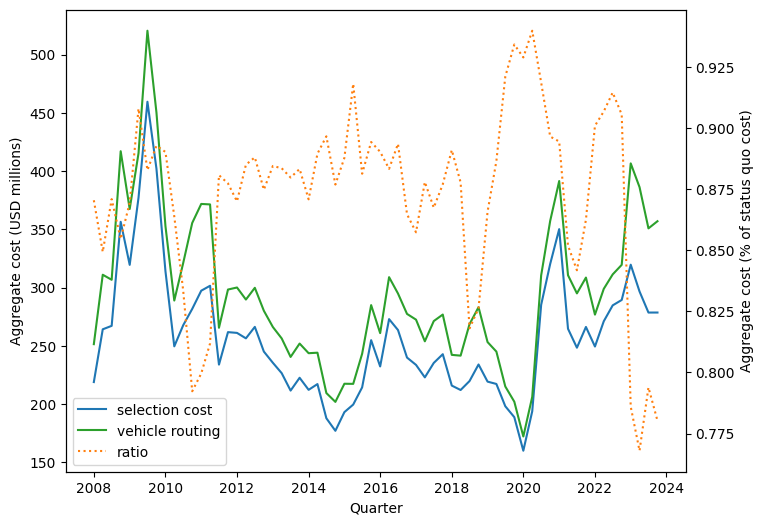

In [14]:
fig, ax1 = plt.subplots(nrows=1,ncols=1,figsize=(8,6))

# Left axis: percentage costs
ax1.plot(
    results_df['quarter'],
    results_df['selection_cost'],
    label="selection cost",
    color="#1f77b4"
)

ax1.plot(
    results_df['quarter'],
    results_df['status_quo'],
    label="vehicle routing",
    color="#2ca02c"
)

ax1.set_xlabel("Quarter")
ax1.set_ylabel(r"Aggregate cost (USD millions)")

# Right axis: ratio
ax2 = ax1.twinx()

ax2.plot(
    results_df['quarter'],
    results_df['selection_cost']/results_df['status_quo'],
    label="ratio",
    color="#ff7f0e",
    linestyle=':'
)

ax2.set_ylabel("Aggregate cost (% of status quo cost)")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.savefig("output/cost_percent_sq_HAC.png", dpi=300, bbox_inches="tight")
# plt.savefig("output/cost_percent_sq_GREEDY.png", dpi=300, bbox_inches="tight")
plt.show()
